In [191]:
import unicodedata

import pandas as pd
from mpmath.libmp import normalize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Dropout,Input,LSTM,Embedding,Normalization
import os
import datasets
from tensorflow.keras.optimizers import Adam
from datasets import Dataset,DatasetDict
import tensorflow as tf
import re
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import yfinance as yf


In [192]:
btc = yf.download('BTC-USD', start='2020-01-01', end='2026-02-19')

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BTC-USD']: TypeError("'NoneType' object is not subscriptable")


In [183]:
btc.to_csv('bitcoin_new.csv')
btc.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,


In [149]:
data=data.iloc[::-1].reset_index(drop=True)

In [150]:
data.isnull().sum()

Open                     0
High                     0
Low                      0
Close                    0
percent_change_24h    1769
Volume                   0
Market Cap               0
dtype: int64

In [151]:
cls= ['Open','High','Low','Close','Volume']

In [152]:
for col in cls:
    data[col]=data[col].astype(str).str.replace(",",'').astype(float)


In [153]:
data=data.dropna(subset=cls)
print(len(data))

2769


In [154]:
split_r=0.8
split=int(len(data)*split_r)
train=data[:split]
test=data[split:]


In [155]:
print("train shape:", train.shape)
print("train head:", train.head())

train shape: (2215, 7)
train head:      Open    High     Low   Close  percent_change_24h  Volume     Market Cap
0  134.44  147.49  134.00  144.54                 NaN     0.0  1,603,768,865
1  144.00  146.93  134.05  139.00                 NaN     0.0  1,542,813,125
2  139.00  139.89  107.72  116.99                 NaN     0.0  1,298,954,594
3  116.38  125.60   92.28  105.21                 NaN     0.0  1,168,517,495
4  106.25  108.13   79.10   97.75                 NaN     0.0  1,085,995,169


In [156]:
from sklearn.preprocessing import MinMaxScaler
i=MinMaxScaler()
train_s=i.fit_transform(train[cls])
test_s=i.transform(test[cls])

In [157]:
data.columns

Index(['Open', 'High', 'Low', 'Close', 'percent_change_24h', 'Volume',
       'Market Cap'],
      dtype='object')

In [158]:
def make_sequence(arr, seq_len=20):
    x = []
    y = []
    for i in range(len(arr) - seq_len):
        x.append(arr[i:i + seq_len])
        y.append(arr[i + seq_len, 3])
    return np.array(x, dtype=np.float32), np.array(y, dtype=np.float32)

In [159]:
x_train, y_train = make_sequence(train_s)
x_test, y_test = make_sequence(test_s)

In [160]:
print(len(train))
print(len(test))

2215
554


In [161]:
print(x_train.shape)

(2195, 20, 5)


In [162]:
model=Sequential()

model.add(LSTM(120,return_sequences=True,input_shape=(20,5)))
model.add(Dropout(0.3))
model.add(LSTM(42,return_sequences=False))
model.add(Dense(1,activation='linear'))

C:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [163]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 20, 120)        │        60,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 20, 120)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 42)             │        27,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            43 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,907 (343.39 KB)

 Trainable params: 87,907 (343.39 KB)

 Non-trainable params: 0 (0.00 B)

In [164]:
model.compile(loss="mse",optimizer=Adam(learning_rate=0.0001),metrics=["mae"])

In [165]:
history=model.fit(x_train,y_train,batch_size=10,epochs=100)

Epoch 1/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0051 - mae: 0.0320
Epoch 2/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - mae: 0.0157
Epoch 3/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0011 - mae: 0.0150
Epoch 4/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.7206e-04 - mae: 0.0136
Epoch 5/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.9584e-04 - mae: 0.0130
Epoch 6/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 8.2764e-04 - mae: 0.0127
Epoch 7/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.8866e-04 - mae: 0.0123
Epoch 8/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.8502e-04 - mae: 0.0113
Epoch 9/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.4320e-04 - mae: 0.0122
Epoch 10/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.4133e-04 - mae: 0.0112
Epoch 11/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3823e-04 - mae: 0.0114
Epoch 12/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.

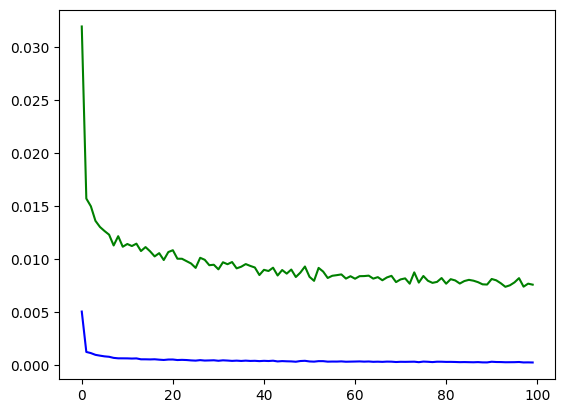

In [166]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"],label="loss",color ="blue")
plt.plot(history.history["mae"],label="mae",color="green")

In [167]:
l20=test_s[-20:]
l20=l20.reshape(1,20,5)
pred=model.predict(l20)
dummy=np.zeros((1,5))
dummy[0,3]=pred[0,0]
pred_price=i.inverse_transform(dummy)[0,3]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


In [168]:
print(f"{pred_price:,.2f}")

16,144.37


In [127]:
print(data.head(3))
print(data.tail(3))

       Open      High       Low     Close  percent_change_24h        Volume  \
0  18729.84  18866.29  16351.03  17150.62               -8.43  6.139684e+10   
1  19104.41  19390.97  18581.15  18732.12               -1.95  4.371036e+10   
2  18365.01  19348.27  18128.66  19107.46                4.04  5.146957e+10   

        Market Cap  
0  318,231,964,319  
1  347,558,803,507  
2  354,504,361,032  
        Open    High     Low   Close  percent_change_24h  Volume  \
2766  139.00  139.89  107.72  116.99                 NaN     0.0   
2767  144.00  146.93  134.05  139.00                 NaN     0.0   
2768  134.44  147.49  134.00  144.54                 NaN     0.0   

         Market Cap  
2766  1,298,954,594  
2767  1,542,813,125  
2768  1,603,768,865  
